In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mobile-legends-google-play-reviews/mobile_legends_reviews.csv


# IMPORT LIBRARIES

****LIBRARİES****

> NLTK (Natural Language Toolkit) is an open-source, powerful, and comprehensive library used to perform natural language processing (NLP) tasks.

 We use it for:
 Stopword Removal,sentiment analysis

> TextBlob is an easy-to-use and intuitive natural language processing (NLP) library written in Python. It is ideal for tasks such as text analysis, sentiment analysis, and language processing.

We use it for:
Spelling correction , lemmetization,sentiment analysis

In [2]:
import pandas as pd

!pip install nltk
import nltk

#For remove stopwords
nltk.download("stopwords")
from nltk.corpus import stopwords

!pip install textblob

#For spelling correction
from textblob import TextBlob

#For lemmetization
from textblob import Word
nltk.download("omw-1.4")
nltk.download("wordnet")

#For wordcloud
!pip install wordcloud
import numpy as np
from os import path
from PIL import Image
!pip install Pillow
from wordcloud import WordCloud,STOPWORDS,ImageColorGenerator

import matplotlib.pyplot as mlt

#For DistilBERT model
!pip install transformers --quiet
from transformers import pipeline
from tqdm import tqdm

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


2025-08-25 17:13:05.225150: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756141985.507472      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756141985.585524      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
df = pd.read_csv('/kaggle/input/mobile-legends-google-play-reviews/mobile_legends_reviews.csv', encoding='UTF-8-SIG')


In [4]:
df.head(10)

,reviewId,userName,content,score,thumbsUpCount,at
0,d9b3706c-a29d-4661-b757-812be9802f33,A Google user,Love this game. Honestly didn't have any expec...,5,0,2025-06-10 13:20:23
1,cc717825-ea2b-444c-8e80-e4f517314880,A Google user,the graphics? 10/10!!! this game is so funn!! 😄,5,0,2025-06-10 13:19:39
2,f3c5353d-65f8-486f-81b0-5ac733ed88a0,A Google user,Horrible. your matchmaking sucks. The players ...,1,0,2025-06-10 13:18:52
3,5d2611d3-dfda-41b5-87e8-d20498b0f4a4,A Google user,"dark system. fix your match making, it makes t...",1,0,2025-06-10 13:15:51
4,38f96ac5-c264-4045-babf-543f576d70b2,A Google user,This game has a so much dark sistem and the li...,1,0,2025-06-10 13:11:34
5,e9de9ff3-bee2-4d16-ab4e-f7835169fb7b,A Google user,Hello I'm an old mlbb player and I suggest low...,1,0,2025-06-10 13:11:23
6,e7b0bb35-36d3-4654-a487-6b1f91619c48,A Google user,Your Game Is Trash My Team Is Tirible Man!!!,1,0,2025-06-10 13:01:03
7,e92bf269-c7a4-43b6-a7f6-19da998a2f26,A Google user,Nice details and nice game,4,0,2025-06-10 12:58:44
8,93e7254a-14b0-4a92-8af8-eef4317a0ce3,A Google user,"AS A SOLO PLAYER, YOUR MATCHMAKING ALGORITHM I...",1,0,2025-06-10 12:58:27
9,679c262e-b755-414e-bc9f-845869109a45,A Google user,lag server even can't move how play,1,0,2025-06-10 12:56:33


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52651 entries, 0 to 52650
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewId       52651 non-null  object
 1   userName       52651 non-null  object
 2   content        52651 non-null  object
 3   score          52651 non-null  int64 
 4   thumbsUpCount  52651 non-null  int64 
 5   at             52651 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.4+ MB


****Is data contains missing data?****


In [6]:
df.isna().sum()

reviewId         0
userName         0
content          0
score            0
thumbsUpCount    0
at               0
dtype: int64

****We will use 'content' and  'score' variables for analysis.****

content: includes user comments about the Mobile Legends game

score: shows ratings/scores given to the Mobile Legends game

In [7]:
data =df[["content","score"]].copy()

In [8]:
data

,content,score
0,Love this game. Honestly didn't have any expec...,5
1,the graphics? 10/10!!! this game is so funn!! 😄,5
2,Horrible. your matchmaking sucks. The players ...,1
3,"dark system. fix your match making, it makes t...",1
4,This game has a so much dark sistem and the li...,1
...,...,...
52646,Lostreak in Ranked game Please help me to impr...,5
52647,This Is Great! I WANNA WIN ALWAYS,5
52648,This game sooo good and make me happy,5
52649,I love this game,5


# DATA CLEANING

Data cleaning for sentiment analysis involves preprocessing text by removing noise such as punctuation, stopwords, HTML tags, emojis, and correcting misspellings to ensure accurate and meaningful sentiment classification.

This process is very important to understand the text more accurate for analysis

In [9]:
#1.Convert all words to lowercase

data["content"] = data["content"].str.lower()

#2.Remove punctuation marks and numbers

data["content"] = data["content"].str.replace(r"[^\w\s]","",regex=True)
data["content"] = data["content"].str.replace(r"\d","",regex=True)

#3.Remove stopwords(Remove words such as “the”, “is”, “in”, ‘and’, “of” that have 
#no meaning but appear frequently)

stp=stopwords.words("english")  
data["content"] = data["content"].apply(lambda x:" ".join(x for x in x.split()if x not in stp))

#4.Remove rarewords
#Rarewords is the name given to words that appear very rarely in a dataset 
#in natural language processing (NLP) and text mining.

#Create a series that keeps track of how many times each word appears in the text.
word_count = pd.Series(' '.join(data["content"]).split()).value_counts()

#Remove words that appear only once.
drops = word_count[word_count <= 1]

data["content"] = pd.DataFrame(data["content"].apply(lambda x: " ".join(x for x in x.split() if x not in drops)))


In [10]:
data

,content,score
0,love game honestly didnt expectations going kn...,5
1,graphics game funn,5
2,horrible matchmaking sucks players either real...,1
3,dark system fix match making makes game enjoyable,1
4,game much dark sistem line always bad lost acc...,1
...,...,...
52646,lostreak ranked game please help improve games,5
52647,great wanna win always,5
52648,game sooo good make happy,5
52649,love game,5


****We can see which words rarewords****

In [11]:
drops

campaign        1
pigs            1
updateidk       1
injur           1
kingdom         1
               ..
scorepenalty    1
hardlgame       1
ponts           1
req             1
aless           1
Name: count, Length: 13109, dtype: int64

****The data contains 13,109 rare words. Removing these words makes the data easier to analyze****

In [12]:
#5.Lemmetization
#Lemmatization is the process of converting a word to its root form in the field 
#of natural language processing (NLP).
#It is used to combine words in different forms into a single representation.
#For example: went and go have the same meaning but indicate different tenses.
#Therefore, the word went is converted to go.



In [13]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
!python -m textblob.download_corpora
from textblob import TextBlob, Word

def lemmatize_text(text):
    blob = TextBlob(text)
    return " ".join([Word(word).lemmatize(pos=tag[0].lower()) if tag[0].lower() in ['a','r','n','v'] else word
                     for word, tag in blob.tags])



[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


[nltk_data] Downloading package brown to /usr/share/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /usr/share/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [14]:
data["content"] = data["content"].apply(lemmatize_text)

In [15]:
data

,content,score
0,love game honestly didnt expectation go know h...,5
1,graphic game funn,5
2,horrible matchmaking suck player either really...,1
3,dark system fix match making make game enjoyable,1
4,game much dark sistem line always bad lose acc...,1
...,...,...
52646,lostreak rank game please help improve game,5
52647,great wan na win always,5
52648,game sooo good make happy,5
52649,love game,5


# WORD ANALYSİS

****Let's see how many times each word appears in the text.****

In [16]:
#Count each word
word_count = data["content"].apply(lambda x: pd.Series(str(x).split(" "))).stack().value_counts().reset_index()
word_count.columns = ["words", "word_count"]

# Sort from most to least
kf_sorted = word_count.sort_values("word_count", ascending=False)

In [17]:
#Top 20 most frequently used words
kf_sorted.head(20)

,words,word_count
0,game,36042
1,play,11545
2,good,9963
3,player,7568
4,matchmaking,6529
5,like,6429
6,get,6073
7,match,5975
8,system,5626
9,fix,5428


> When we look at the most frequently used words, we see that most of them are related to games.    ('game','play','player','matchmaking','match'..)

> Positive words('good','like','love')

> Negative words('dont')

****WORDCLOUD****

It creates a visual based on the number of times words appear in a text.

The most frequently repeated words are written in the largest font.

(-0.5, 399.5, 199.5, -0.5)

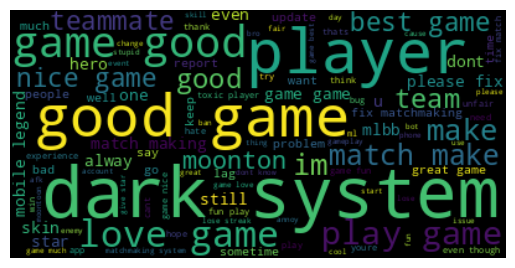

In [18]:
# Wordcloud works with string 
#data["content"] is a series so we should convert it to string

text = " ".join(data["content"])

wrdc1 = WordCloud(
    width=400,
    height=200,
    background_color='black',
    max_words=100 
).generate(text)

mlt.imshow(wrdc1,interpolation="bilinear")
mlt.axis("off")

# SENTIMENT ANALYSIS



> What is sentiment analysis?

Sentiment Analysis is a natural language processing (NLP) technique used to identify emotional expressions (such as positive, negative, or neutral) in a text. It is particularly used to analyze emotions in texts such as social media posts, product reviews, and customer feedback.

> Which models we can use for sentiment analysis?

****1. Lexicon-Based Methods****

These use predefined dictionaries of sentiment-bearing words.

* Examples: VADER, TextBlob

* Simple and fast, but not good at understanding sarcasm or context.

* Best for: Small-scale, quick analyses

****2. Machine Learning Models****

These models are trained on labeled data (e.g., positive or negative).
Text is first converted into numerical features using techniques like TF-IDF or CountVectorizer.

Common Algorithms:

* Logistic Regression

* Naive Bayes

* SVM (Support Vector Machines)

* Random Forest

Requires balanced and labeled datasets to perform well.

****3. Deep Learning Models****

More powerful models that work well on larger datasets and complex linguistic structures.

Examples:
* LSTM (Long Short-Term Memory): Great for sequential data.

* CNN (Convolutional Neural Networks): Works well on short texts.

* Variants like Bi-LSTM, GRU, etc.


****4. Transformer-Based Models (Most Advanced and Accurate)****

 Examples:

* BERT (Bidirectional Encoder Representations from Transformers)

* DistilBERT → A smaller, faster version of BERT

* RoBERTa, XLNet, ALBERT


These models understand context deeply, making them better at handling sarcasm, irony, and ambiguous language.

> I will use DistilBERT model for sentiment analysis.DistilBERT is a lighter and faster version of BERT.

The distilbert-base-uncased-finetuned-sst-2-english model on Hugging Face has already been trained for sentiment analysis.




****Transformer-based models****

Transformer-based models  work as follows:

Input Representation (Embeddings):
Each word or subword in the text is converted into a numerical vector.

Self-Attention Mechanism:
The model learns how each word relates to all other words. In other words, every word “pays attention” to the others, and its meaning is shaped by the context.

Layers:
This self-attention process is repeated across multiple layers, allowing the model to capture both short-range and long-range dependencies in the text.

Output:
Depending on the training objective (prediction, classification, translation, text generation, etc.), the model produces the final outputs.


# DistilBERT Model

> ****What is pipeline?****

A pipeline is a structure that combines data preprocessing steps with model training and prediction processes in a sequential and organized manner in machine learning or natural language processing projects.

> I will use pipeline for model. 

pipeline("sentiment-analysis")

This command actually performs four steps automatically:

* Tokenization: The sentence is broken down into words and converted into numbers (IDs).

* Model prediction: DistilBERT processes these tokens and produces an output (logit).

* Softmax: Logit values are converted to 0–1 (probability).

* Label assignment: The label with the highest score is assigned.

In [19]:
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=-1)


texts = data["content"].astype(str).apply(lambda x: x[:512]).tolist()

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


To perform efficient sentiment analysis on a large text dataset with DistilBERT, I fed the texts to the model in batches to gain speed.

I choose batch size 32 it means each time, a group (batch) of 32 meters is given to the model.

As a result we will have "sentiment" and "score" variables

Sentiment:Positive or negative
Score:Confidence level of the model (0.0–1.0)

In [20]:
batch_size = 32  

results = []
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    preds = sentiment_model(batch)
    results.extend(preds)


data["sentiment"] = [r["label"] for r in results]
data["score"] = [r["score"] for r in results]

100%|██████████| 1646/1646 [26:21<00:00,  1.04it/s]


In [21]:
data

,content,score,sentiment
0,love game honestly didnt expectation go know h...,0.993961,POSITIVE
1,graphic game funn,0.999144,POSITIVE
2,horrible matchmaking suck player either really...,0.999617,NEGATIVE
3,dark system fix match making make game enjoyable,0.999686,POSITIVE
4,game much dark sistem line always bad lose acc...,0.998135,NEGATIVE
...,...,...,...
52646,lostreak rank game please help improve game,0.996138,POSITIVE
52647,great wan na win always,0.999667,POSITIVE
52648,game sooo good make happy,0.999872,POSITIVE
52649,love game,0.999793,POSITIVE


****Positive vs. Negative Distribution (Bar Chart)****

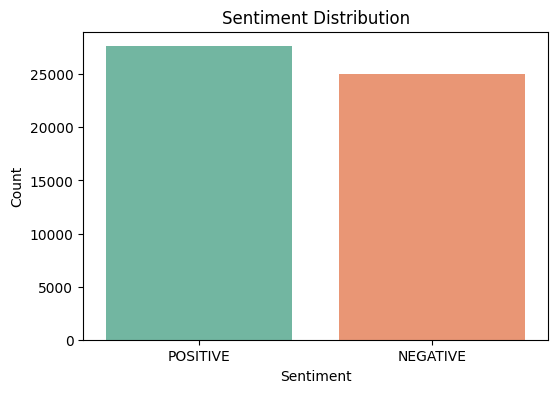

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Plot the distribution of emotions
sns.countplot(data=data, x="sentiment", palette="Set2")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [23]:
#Frequency of sentiments
sentiment_counts = data["sentiment"].value_counts()
print(sentiment_counts)

sentiment
POSITIVE    27624
NEGATIVE    25027
Name: count, dtype: int64


When we performed classification using DistilBERT;

 27624 comment was classified as positive 
 
 25027 comments were classified as negative.

# MODEL EVALUATION

To evaluate the performance of the sentiment classification model, we used 

**accuracy score**

**confusion matrix**

**classification report (precision, recall, F1-score)**
 
 These metrics provide a comprehensive view of the model’s effectiveness in predicting sentiments.

In [24]:
data["ratings"]=df["score"]


In [25]:
def map_sentiment(x):
    if x <= 2:   
        return "NEGATIVE"
    
    else:        
        return "POSITIVE"

data["real_sentiment"] = data["ratings"].apply(map_sentiment)

In [26]:
data

,content,score,sentiment,ratings,real_sentiment
0,love game honestly didnt expectation go know h...,0.993961,POSITIVE,5,POSITIVE
1,graphic game funn,0.999144,POSITIVE,5,POSITIVE
2,horrible matchmaking suck player either really...,0.999617,NEGATIVE,1,NEGATIVE
3,dark system fix match making make game enjoyable,0.999686,POSITIVE,1,NEGATIVE
4,game much dark sistem line always bad lose acc...,0.998135,NEGATIVE,1,NEGATIVE
...,...,...,...,...,...
52646,lostreak rank game please help improve game,0.996138,POSITIVE,5,POSITIVE
52647,great wan na win always,0.999667,POSITIVE,5,POSITIVE
52648,game sooo good make happy,0.999872,POSITIVE,5,POSITIVE
52649,love game,0.999793,POSITIVE,5,POSITIVE


In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [28]:
print( confusion_matrix(data["real_sentiment"],data["sentiment"]))

[[19702  3199]
 [ 5325 24425]]


****Heatmap****

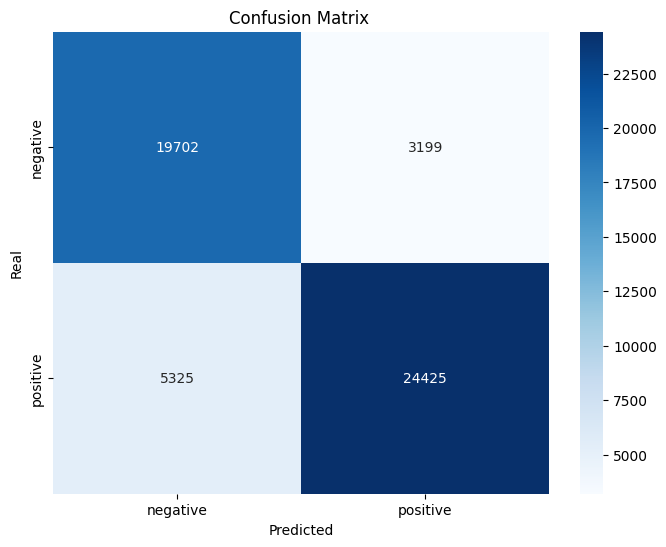

In [29]:
cm = np.array([
    [19702,  3199],
    [ 5325 ,24425]])

labels = ["negative", "positive"]
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix ")
plt.show()

19702 → The model correctly predicted NEGATIVE 

3199 → The model predicted POSITIVE for an actual NEGATIVE 

5325 → The model predicted NEGATIVE for an actual POSITIVE 

24425 → The model correctly predicted POSITIVE 

****Classification Report****

In [30]:
print( classification_report(data["real_sentiment"],data["sentiment"]))

              precision    recall  f1-score   support

    NEGATIVE       0.79      0.86      0.82     22901
    POSITIVE       0.88      0.82      0.85     29750

    accuracy                           0.84     52651
   macro avg       0.84      0.84      0.84     52651
weighted avg       0.84      0.84      0.84     52651



Precision: Of all the instances predicted as positive, how many are actually positive.


Recall: Of all the actual positive instances, how many did the model correctly identify.



****Accuracy****

In [31]:
print( accuracy_score(data["real_sentiment"],data["sentiment"]))

0.8381037397200433


Accuracy: The most basic measure of success, showing how many of the model's predictions are correct.

Overall accuracy of the model %83.8